In [147]:
# 1. Setup
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import matplotlib.pyplot as plt

import copy
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score

np.random.seed(42)
torch.manual_seed(42)


In [148]:
# 2. Data Definition
# Features: [HP, Ammo, Distance, Visibility, Suppressed]
# Labels: 0 (Retreat), 1 (Hold), 2 (Attack)
# 각 클래스를 두 서브그룹으로 구성 → 비볼록 결정 경계 형성
# Retreat Sub-B: HP 높음에도 Suppressed=1 이면 후퇴 (HP×Suppressed XOR 구조)
# Attack Sub-B: 중간 HP지만 탄약 풍부 (HP×Ammo 상호작용)
# 5% 레이블 노이즈로 overfitting 유발


def get_dataset(n=1800):
    rng = np.random.default_rng(42)
    n_per = n // 3  # 600 each

    # Retreat (0)
    h = n_per // 2
    # Sub-A: HP 매우 낮고 거리가 멀어 교전 불가
    X0a = np.column_stack(
        [
            rng.uniform(0, 40, h),  # HP: very low
            rng.uniform(0, 20, h),  # Ammo
            rng.uniform(55, 100, h),  # Distance: far
            rng.integers(0, 2, h),  # Visibility
            rng.choice([0, 1], h, p=[0.4, 0.6]),  # Suppressed: biased
        ]
    )
    # Sub-B: HP는 높지만 제압당함
    X0b = np.column_stack(
        [
            rng.uniform(55, 95, n_per - h),  # HP: high (!)
            rng.uniform(0, 15, n_per - h),  # Ammo: low
            rng.uniform(5, 45, n_per - h),  # Distance: close
            rng.choice([0, 1], n_per - h, p=[0.6, 0.4]),
            np.ones(n_per - h),  # Suppressed: always 1
        ]
    )
    X0 = np.vstack([X0a, X0b])

    # Hold (1)
    X1 = np.column_stack(
        [
            rng.uniform(25, 80, n_per),
            rng.uniform(6, 24, n_per),
            rng.uniform(20, 85, n_per),
            rng.integers(0, 2, n_per),
            rng.integers(0, 2, n_per),
        ]
    )

    # Attack (2)
    h2 = n_per // 2
    # Sub-A: HP 높고 근접, 가시성 확보, 비제압
    X2a = np.column_stack(
        [
            rng.uniform(60, 100, h2),  # HP: high
            rng.uniform(10, 30, h2),  # Ammo
            rng.uniform(5, 40, h2),  # Distance: close
            np.ones(h2),  # Visible: always
            np.zeros(h2),  # Suppressed: never
        ]
    )
    # Sub-B: 중간 HP지만 탄약 풍부 + 가시성
    X2b = np.column_stack(
        [
            rng.uniform(45, 75, n_per - h2),  # HP: medium
            rng.uniform(22, 30, n_per - h2),  # Ammo: very high (!)
            rng.uniform(25, 65, n_per - h2),
            rng.choice([0, 1], n_per - h2, p=[0.15, 0.85]),
            np.zeros(n_per - h2),  # Suppressed: never
        ]
    )
    X2 = np.vstack([X2a, X2b])

    X = np.vstack([X0, X1, X2])
    y = np.repeat([0, 1, 2], n_per)

    # 5% label noise
    noise_idx = rng.choice(len(y), size=int(len(y) * 0.05), replace=False)
    y[noise_idx] = rng.integers(0, 3, size=len(noise_idx))

    perm = rng.permutation(len(y))
    return X[perm], y[perm]


X, y = get_dataset()
unique, counts = np.unique(y, return_counts=True)
print(
    f"X={X.shape}  "
    + "  ".join(f"{c}:{n}" for c, n in zip(["Retreat", "Hold", "Attack"], counts))
)


X=(1800, 5)  Retreat:597  Hold:608  Attack:595


In [149]:
# 3. Data Visualization
feature_names = ["HP", "Ammo", "Distance", "Visibility", "Suppressed"]
class_names = ["Retreat", "Hold", "Attack"]
colors = ["#e74c3c", "#3498db", "#2ecc71"]


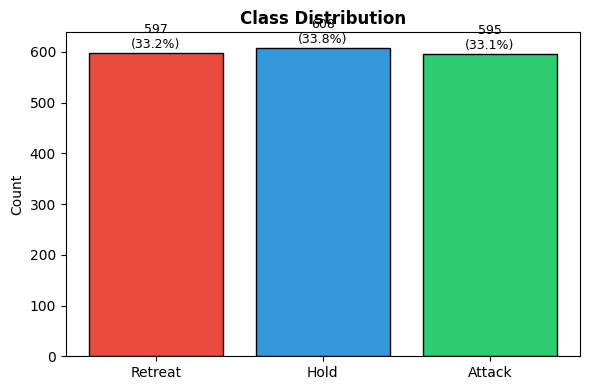

In [150]:
# Class Distribution
fig, ax = plt.subplots(figsize=(6, 4))
unique, counts = np.unique(y, return_counts=True)
bars = ax.bar(class_names, counts, color=colors, edgecolor="black")
for i, (c, cnt) in enumerate(zip(class_names, counts)):
    ax.text(i, cnt + 10, f"{cnt}\n({cnt / len(y) * 100:.1f}%)", ha="center", fontsize=9)
ax.set_title("Class Distribution", fontweight="bold")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()


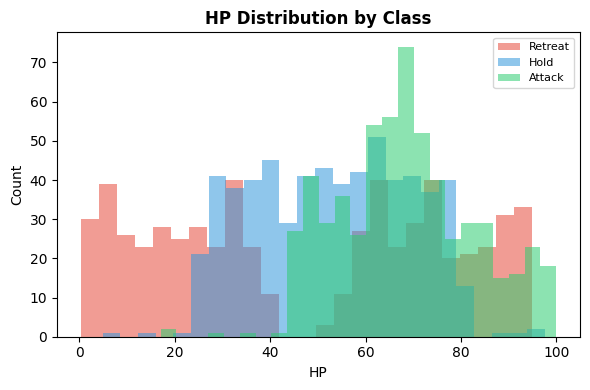

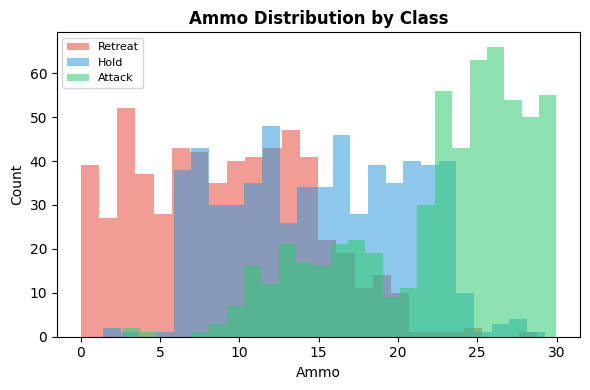

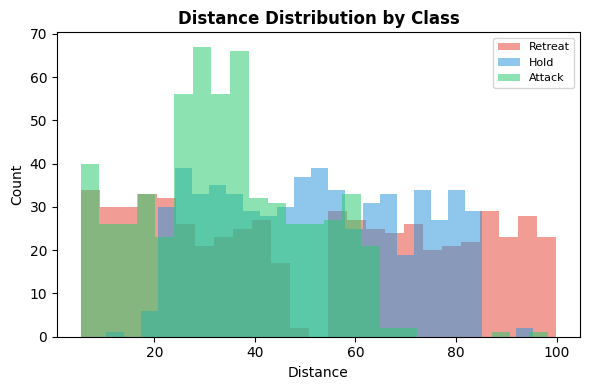

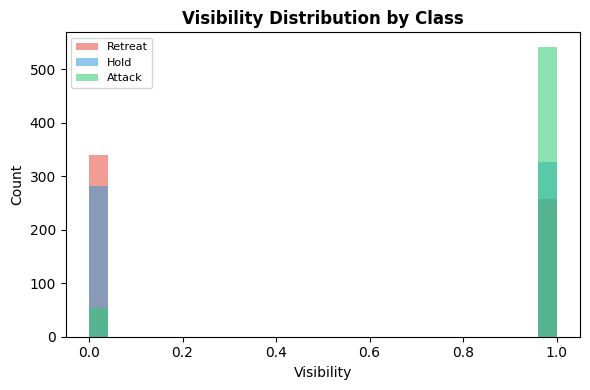

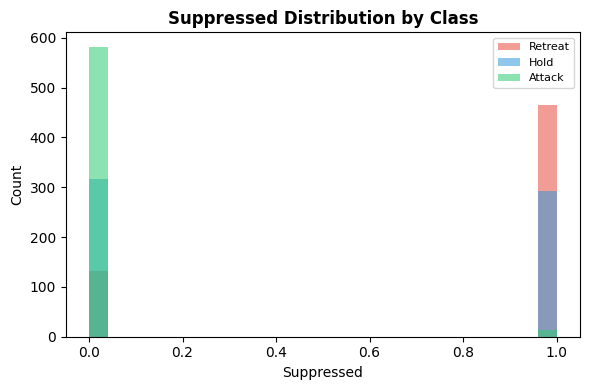

In [151]:
# Feature Distributions by Class
def plot_feature_hist(feature_idx, feature_name):
    fig, ax = plt.subplots(figsize=(6, 4))
    for cls_idx, (cls_name, color) in enumerate(zip(class_names, colors)):
        ax.hist(
            X[y == cls_idx, feature_idx],
            bins=25,
            alpha=0.55,
            label=cls_name,
            color=color,
            edgecolor="none",
        )
    ax.set_title(f"{feature_name} Distribution by Class", fontweight="bold")
    ax.set_xlabel(feature_name)
    ax.set_ylabel("Count")
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()


for fi, fname in enumerate(feature_names):
    plot_feature_hist(fi, fname)


In [152]:
# 4. Preprocessing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Validation split from training data (80 / 20)
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.2, stratify=y_train, random_state=42
)

scaler = StandardScaler()
X_tr = scaler.fit_transform(X_tr)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

t_X_tr = torch.tensor(X_tr, dtype=torch.float32)
t_y_tr = torch.tensor(y_tr, dtype=torch.long)
t_X_val = torch.tensor(X_val, dtype=torch.float32)
t_y_val = torch.tensor(y_val, dtype=torch.long)
t_X_test = torch.tensor(X_test, dtype=torch.float32)
t_y_test = torch.tensor(y_test, dtype=torch.long)

train_loader = DataLoader(TensorDataset(t_X_tr, t_y_tr), batch_size=32, shuffle=True)
val_loader = DataLoader(TensorDataset(t_X_val, t_y_val), batch_size=32)
test_loader = DataLoader(TensorDataset(t_X_test, t_y_test), batch_size=32)

print(f"Split  train={len(t_X_tr)}  val={len(t_X_val)}  test={len(t_X_test)}")


Split  train=1152  val=288  test=360


In [153]:
# 5. Model Definition
class MLP(nn.Module):
    def __init__(
        self, net_arch, in_features=5, out_features=3, dropout=0.0, use_bn=False
    ):
        super().__init__()
        layers = []
        prev = in_features
        for hidden in net_arch:
            layers.append(nn.Linear(prev, hidden))
            if use_bn:
                layers.append(nn.BatchNorm1d(hidden))
            layers.append(nn.ReLU())
            if dropout > 0.0:
                layers.append(nn.Dropout(dropout))
            prev = hidden
        layers.append(nn.Linear(prev, out_features))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


In [154]:
# 6. Train Pipeline
EPOCHS = 200


def train(model, train_loader, val_loader, lr, patience, wd):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=wd)
    train_hist, val_hist = [], []
    best_val_loss = float("inf")
    best_state = None
    no_improve = 0

    for epoch in range(EPOCHS):
        # Train
        model.train()
        epoch_loss = 0
        for xb, yb in train_loader:
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        train_hist.append(epoch_loss / len(train_loader))

        # Validate
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for xb, yb in val_loader:
                val_loss += criterion(model(xb), yb).item()
        val_loss /= len(val_loader)
        val_hist.append(val_loss)

        # Early Stopping
        if val_loss < best_val_loss - 1e-4:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                break

    model.load_state_dict(best_state)
    return train_hist, val_hist


def evaluate(model, loader):
    model.eval()
    all_preds, all_true = [], []
    with torch.no_grad():
        for xb, yb in loader:
            all_preds.extend(model(xb).argmax(dim=1).numpy())
            all_true.extend(yb.numpy())
    acc = accuracy_score(all_true, all_preds)
    f1 = f1_score(all_true, all_preds, average="macro")
    return acc, f1


def plot_experiment(model, name, train_hist, val_hist):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

    # Loss curve
    ax1.plot(train_hist, label="Train Loss", linewidth=2)
    ax1.plot(val_hist, label="Val Loss", linewidth=2, linestyle="--")
    best_ep = int(val_hist.index(min(val_hist)))
    ax1.axvline(
        best_ep,
        color="gray",
        linestyle=":",
        linewidth=1.5,
        label=f"Best epoch {best_ep}",
    )
    ax1.set_title(f"{name} — Loss Curve", fontweight="bold")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Loss")
    ax1.legend()

    # Confusion matrix
    model.eval()
    all_preds, all_true = [], []
    with torch.no_grad():
        for xb, yb in test_loader:
            all_preds.extend(model(xb).argmax(dim=1).numpy())
            all_true.extend(yb.numpy())
    acc = accuracy_score(all_true, all_preds)
    f1 = f1_score(all_true, all_preds, average="macro")
    cm = confusion_matrix(all_true, all_preds)

    im = ax2.imshow(cm, interpolation="nearest", cmap="Blues")
    ax2.set_title(
        f"{name}\nAcc: {acc * 100:.2f}%  |  F1(macro): {f1:.4f}", fontweight="bold"
    )
    ax2.set_xticks(range(len(class_names)))
    ax2.set_yticks(range(len(class_names)))
    ax2.set_xticklabels(class_names, rotation=15)
    ax2.set_yticklabels(class_names)
    ax2.set_xlabel("Predicted")
    ax2.set_ylabel("True")
    thresh = cm.max() / 2
    for i in range(len(class_names)):
        for j in range(len(class_names)):
            ax2.text(
                j,
                i,
                str(cm[i, j]),
                ha="center",
                va="center",
                color="white" if cm[i, j] > thresh else "black",
                fontsize=11,
            )
    plt.colorbar(im, ax=ax2)
    plt.tight_layout()
    plt.show()


In [157]:
# 7. Experiment Definition
# 단일 아키텍처 [128, 64, 32] 고정, 정규화 기법을 하나씩 추가하는 ablation study
# Shallow [16] 은 underfitting 기준선

_ARCH = [128, 64, 32]

_C = [
    "#7f8c8d",  # Shallow
    "#e74c3c",  # Base
    "#e67e22",  # +Drop/P30
    "#f39c12",  # +Drop/P60
    "#2980b9",  # +BN
    "#1abc9c",  # +BN+Drop
    "#9b59b6",  # +LR↓
    "#8e44ad",  # +BN+LR↓
    "#27ae60",  # +WD
    "#16a085",  # +BN+WD
]

EXPERIMENTS = [
    # 기준선
    {
        "name": "Shallow",
        "net_arch": [16],
        "dropout": 0.0,
        "use_bn": False,
        "lr": 0.01,
        "patience": 30,
        "wd": 0.0,
    },
    {
        "name": "Base",
        "net_arch": _ARCH,
        "dropout": 0.0,
        "use_bn": False,
        "lr": 0.01,
        "patience": 30,
        "wd": 0.0,
    },
    # +Dropout
    {
        "name": "+Drop/P30",
        "net_arch": _ARCH,
        "dropout": 0.3,
        "use_bn": False,
        "lr": 0.01,
        "patience": 30,
        "wd": 0.0,
    },
    {
        "name": "+Drop/P60",
        "net_arch": _ARCH,
        "dropout": 0.3,
        "use_bn": False,
        "lr": 0.01,
        "patience": 60,
        "wd": 0.0,
    },
    # +BatchNorm
    {
        "name": "+BN",
        "net_arch": _ARCH,
        "dropout": 0.0,
        "use_bn": True,
        "lr": 0.01,
        "patience": 30,
        "wd": 0.0,
    },
    {
        "name": "+BN+Drop",
        "net_arch": _ARCH,
        "dropout": 0.3,
        "use_bn": True,
        "lr": 0.01,
        "patience": 60,
        "wd": 0.0,
    },
    # +LR 변경
    {
        "name": "+LR↓",
        "net_arch": _ARCH,
        "dropout": 0.0,
        "use_bn": False,
        "lr": 0.001,
        "patience": 50,
        "wd": 0.0,
    },
    {
        "name": "+BN+LR↓",
        "net_arch": _ARCH,
        "dropout": 0.0,
        "use_bn": True,
        "lr": 0.001,
        "patience": 50,
        "wd": 0.0,
    },
    # +Weight Decay
    {
        "name": "+WD",
        "net_arch": _ARCH,
        "dropout": 0.0,
        "use_bn": False,
        "lr": 0.01,
        "patience": 30,
        "wd": 1e-3,
    },
    {
        "name": "+BN+WD",
        "net_arch": _ARCH,
        "dropout": 0.0,
        "use_bn": True,
        "lr": 0.01,
        "patience": 30,
        "wd": 1e-3,
    },
]

for exp, c in zip(EXPERIMENTS, _C):
    exp["color"] = c

print(f"Total experiments: {len(EXPERIMENTS)}")


Total experiments: 10


In [158]:
# 8. Training
results = []
for exp in EXPERIMENTS:
    model = MLP(net_arch=exp["net_arch"], dropout=exp["dropout"], use_bn=exp["use_bn"])
    tr_hist, val_hist = train(
        model,
        train_loader,
        val_loader,
        lr=exp["lr"],
        patience=exp["patience"],
        wd=exp["wd"],
    )
    acc, f1 = evaluate(model, test_loader)
    print(f"{exp['name']:<18}  ep={len(tr_hist):>3}  acc={acc:.4f}  f1={f1:.4f}")
    results.append(
        {
            "name": exp["name"],
            "net_arch": exp["net_arch"],
            "dropout": exp["dropout"],
            "use_bn": exp["use_bn"],
            "lr": exp["lr"],
            "patience": exp["patience"],
            "wd": exp["wd"],
            "model": model,
            "train": tr_hist,
            "val": val_hist,
            "color": exp["color"],
        }
    )


Shallow             ep= 48  acc=0.8611  f1=0.8607
Base                ep= 78  acc=0.8917  f1=0.8907
+Drop/P30           ep= 84  acc=0.8722  f1=0.8707
+Drop/P60           ep= 90  acc=0.8639  f1=0.8620
+BN                 ep= 37  acc=0.8694  f1=0.8674
+BN+Drop            ep=105  acc=0.8639  f1=0.8623
+LR↓                ep= 77  acc=0.8722  f1=0.8713
+BN+LR↓             ep= 83  acc=0.8639  f1=0.8626
+WD                 ep= 39  acc=0.8694  f1=0.8687
+BN+WD              ep= 84  acc=0.8750  f1=0.8738


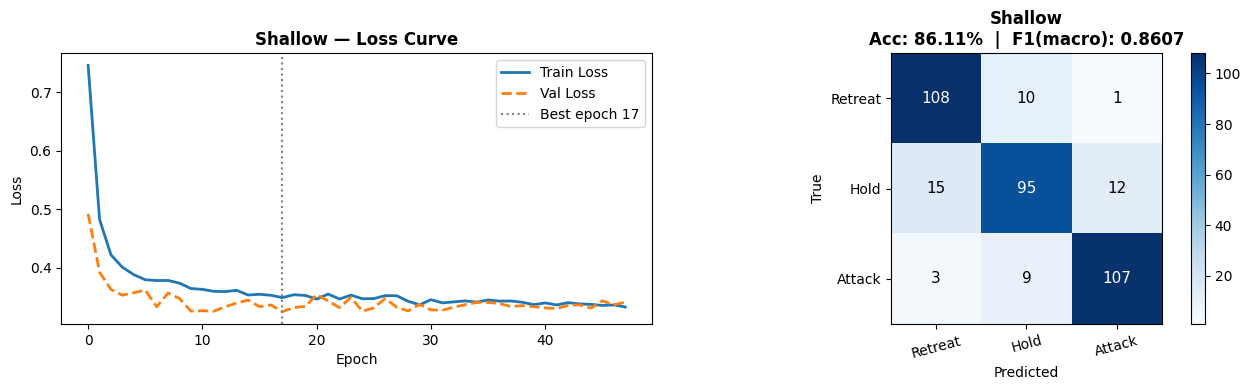

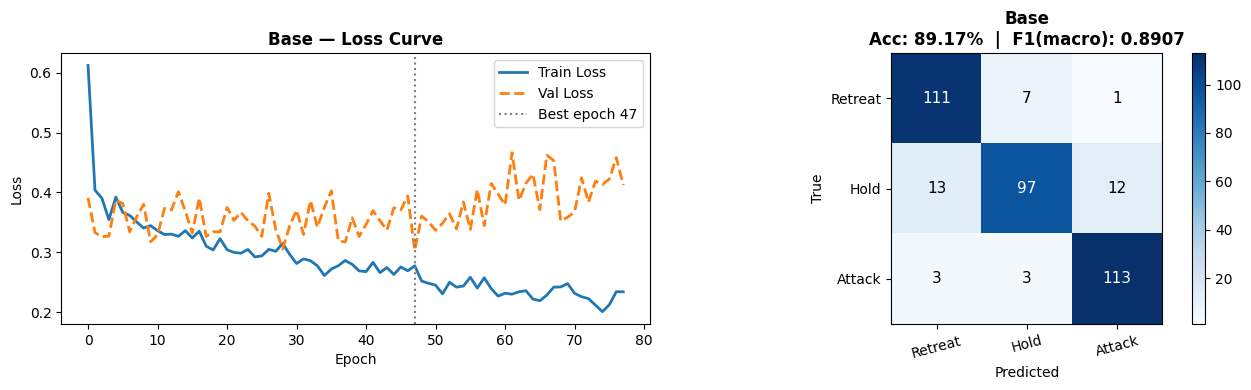

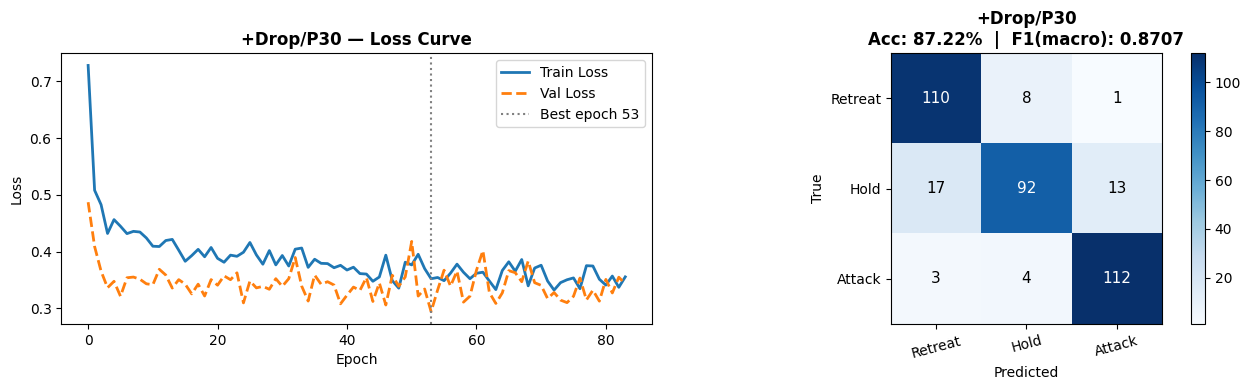

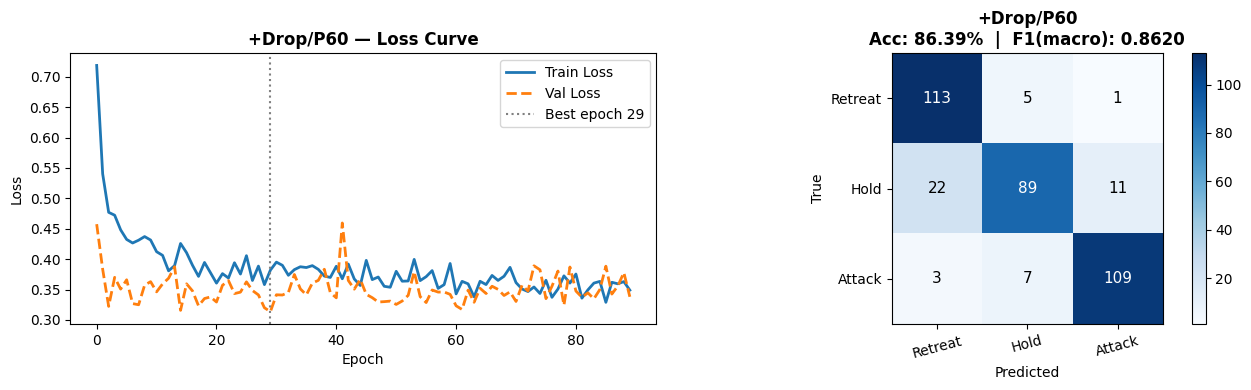

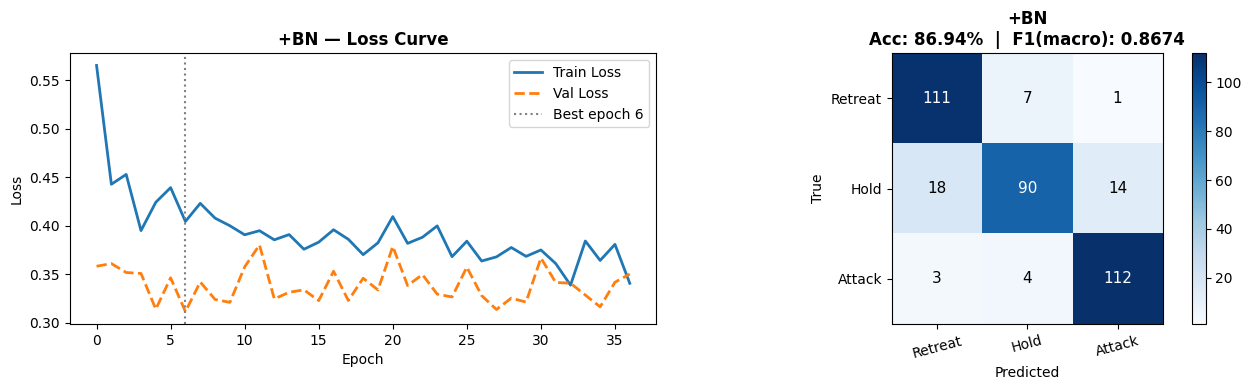

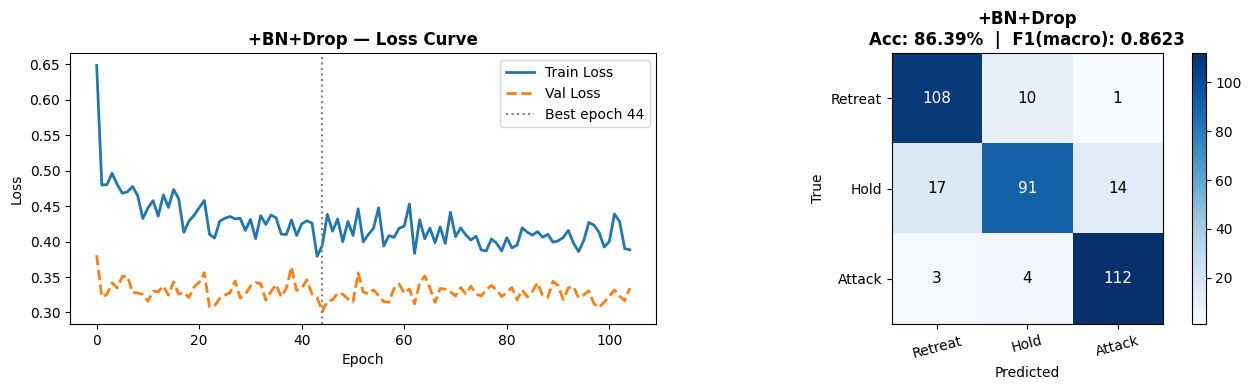

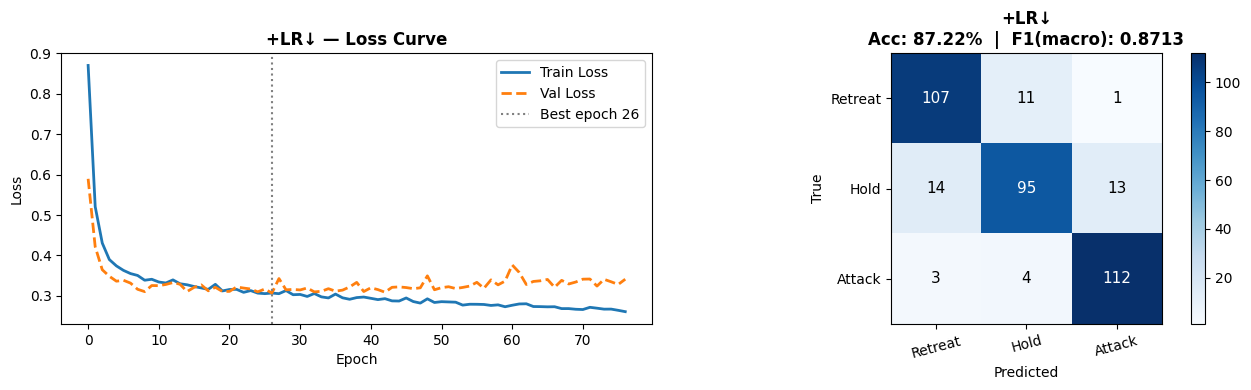

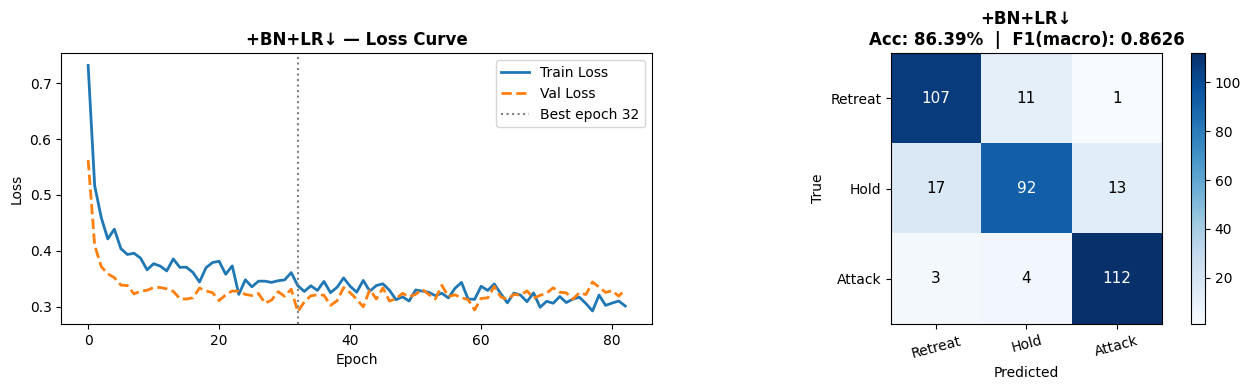

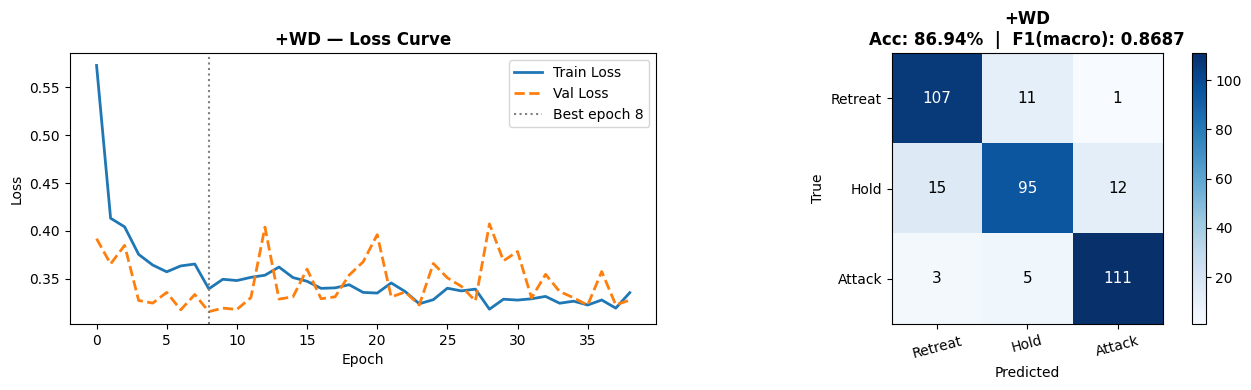

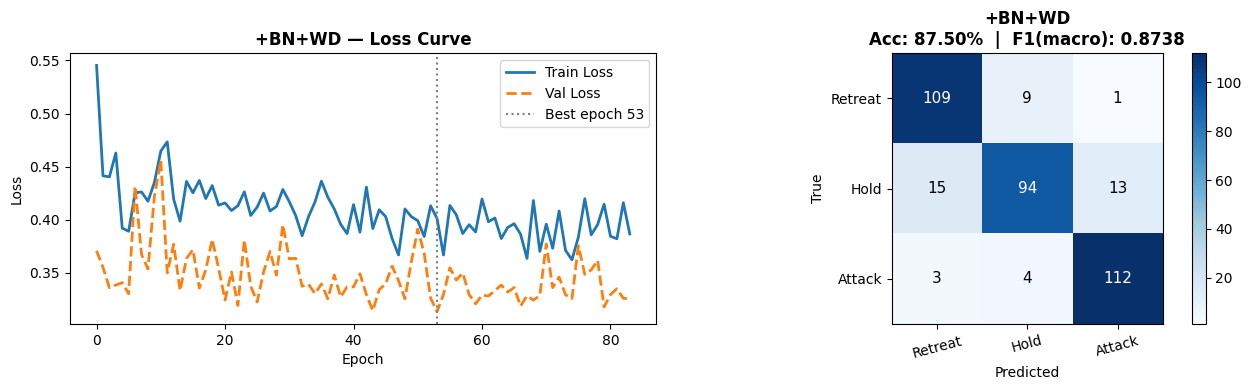

In [159]:
# 9. Per-experiment Plots
for r in results:
    plot_experiment(r["model"], r["name"], r["train"], r["val"])


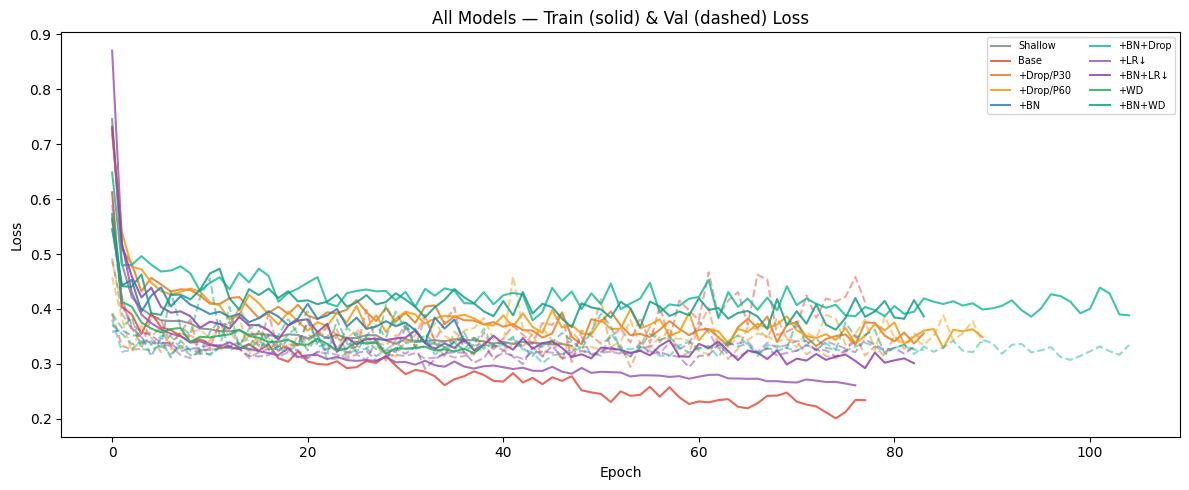

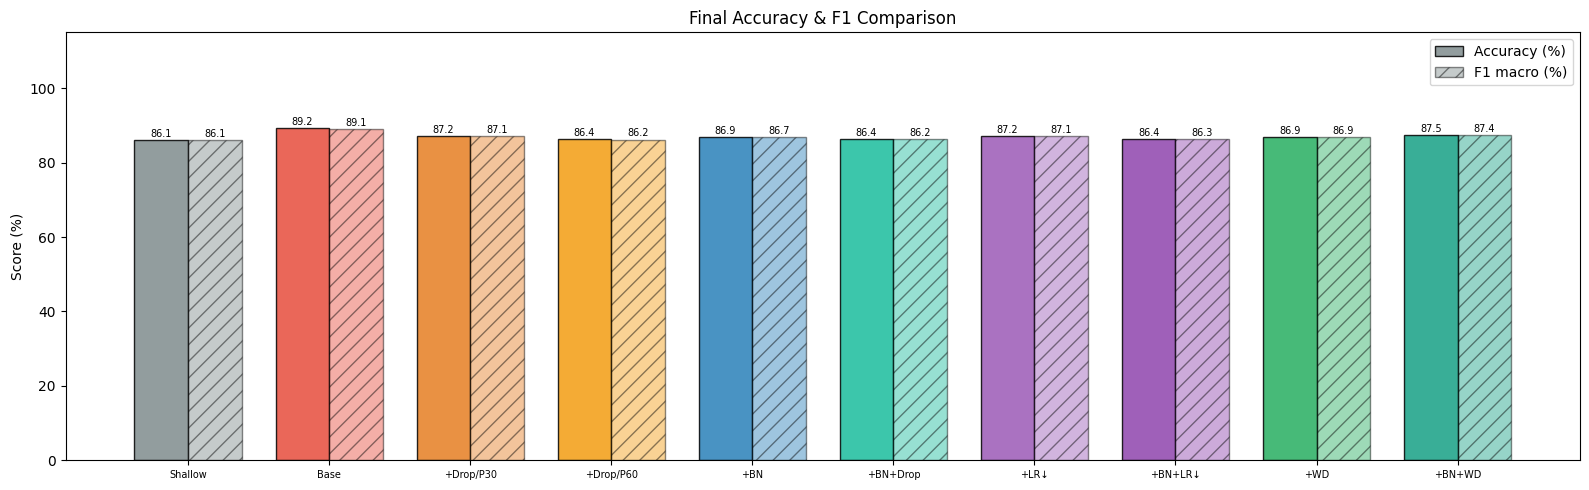

In [160]:
# 10. Final Comparison
exp_colors = [r["color"] for r in results]
metrics = [evaluate(r["model"], test_loader) for r in results]
accuracies = [m[0] for m in metrics]
f1_scores = [m[1] for m in metrics]

# All loss curves
fig, ax = plt.subplots(figsize=(12, 5))
for r in results:
    ax.plot(
        r["train"],
        color=r["color"],
        linewidth=1.5,
        alpha=0.85,
        label=r["name"],
    )
    ax.plot(r["val"], color=r["color"], linewidth=1.5, alpha=0.5, linestyle="--")
ax.set_title("All Models — Train (solid) & Val (dashed) Loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.legend(fontsize=7, ncol=2, loc="upper right")
plt.tight_layout()
plt.show()

# Accuracy & F1 grouped bar
n = len(results)
x = np.arange(n)
width = 0.38
labels = [r["name"].strip() for r in results]
fig, ax = plt.subplots(figsize=(max(16, n * 0.9), 5))
bars_acc = ax.bar(
    x - width / 2,
    [a * 100 for a in accuracies],
    width,
    label="Accuracy (%)",
    color=exp_colors,
    edgecolor="black",
    alpha=0.85,
)
bars_f1 = ax.bar(
    x + width / 2,
    [f * 100 for f in f1_scores],
    width,
    label="F1 macro (%)",
    color=exp_colors,
    edgecolor="black",
    alpha=0.45,
    hatch="//",
)
for bar, val in list(zip(bars_acc, accuracies)) + list(zip(bars_f1, f1_scores)):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.3,
        f"{val * 100:.1f}",
        ha="center",
        va="bottom",
        fontsize=7,
    )
ax.set_ylim(0, 115)
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=7)
ax.set_ylabel("Score (%)")
ax.set_title("Final Accuracy & F1 Comparison")
ax.legend()
plt.tight_layout()
plt.show()


In [161]:
# 11. 결과 수치 정리
print(
    f"{'실험명':<18}  {'BN':>2}  {'lr':>6}  {'P':>3}  {'WD':>8}  {'ep':>4}  {'TrainL':>7}  {'ValL':>7}  {'Acc':>7}  {'F1':>7}  {'gap':>8}"
)
print("─" * 95)
for r in results:
    best_val = min(r["val"])
    final_tr = r["train"][-1]
    gap = final_tr - best_val
    acc, f1 = evaluate(r["model"], test_loader)
    print(
        f"  {r['name']:<18}  {'Y' if r['use_bn'] else 'N':>2}  "
        f"{r['lr']:>6.4f}  {r['patience']:>3}  {r['wd']:>8.2e}  {len(r['train']):>4}  "
        f"{final_tr:>7.4f}  {best_val:>7.4f}  {acc:>7.4f}  {f1:>7.4f}  {gap:>+8.4f}"
    )


실험명                 BN      lr    P        WD    ep   TrainL     ValL      Acc       F1       gap
───────────────────────────────────────────────────────────────────────────────────────────────
  Shallow              N  0.0100   30  0.00e+00    48   0.3329   0.3249   0.8611   0.8607   +0.0080
  Base                 N  0.0100   30  0.00e+00    78   0.2339   0.3032   0.8917   0.8907   -0.0693
  +Drop/P30            N  0.0100   30  0.00e+00    84   0.3556   0.2943   0.8722   0.8707   +0.0613
  +Drop/P60            N  0.0100   60  0.00e+00    90   0.3489   0.3136   0.8639   0.8620   +0.0353
  +BN                  Y  0.0100   30  0.00e+00    37   0.3408   0.3117   0.8694   0.8674   +0.0292
  +BN+Drop             Y  0.0100   60  0.00e+00   105   0.3884   0.3011   0.8639   0.8623   +0.0873
  +LR↓                 N  0.0010   50  0.00e+00    77   0.2608   0.3068   0.8722   0.8713   -0.0460
  +BN+LR↓              Y  0.0010   50  0.00e+00    83   0.3011   0.2909   0.8639   0.8626   +0.0101
  +WD 

### Q1. 게임 AI 문제와 설계 이유

전술 NPC 행동 분류 문제: Retreat(0) / Hold(1) / Attack(2)

전투 상황에서 NPC의 상태를 5개 피처 [HP, Ammo, Distance, Visibility, Suppressed] 로 표현하고,
상황에 적합한 행동을 MLP가 결정하도록 설계하였다.

단순한 선형 경계만으로는 분류할 수 없는 비선형 결정 경계를 만들기 위해 각 클래스를
두 개의 서브그룹으로 구성하였다.

- Retreat Sub-B: HP가 높음에도(55–95) Suppressed=1 이면 후퇴해야 함.
  Attack Sub-A와 HP 범위가 겹치지만 Suppressed 값으로만 구분되는 XOR 구조이다.
- Attack Sub-B: HP가 중간(45–75)이지만 탄약이 풍부(22–30)할 때 공격 가능.
  HP × Ammo 상호작용이 필요하다.

이 비선형 상호작용은 단층(Shallow) 모델이 포착하기 어렵고 충분한 깊이를 가진 모델이 필요하다.
5% 레이블 노이즈를 추가해 정규화 없는 깊은 모델에서 overfitting이 발생하도록 설계하였다.

---

### Q2. 가장 중요한 피처

HP 와 Suppressed 의 상호작용이 가장 결정적이다.

| 피처       | 역할                                                                             |
| ---------- | -------------------------------------------------------------------------------- |
| HP         | 낮은 HP → Retreat Sub-A, 높은 HP → Retreat Sub-B 또는 Attack (Suppressed로 구분) |
| Suppressed | HP가 높은 샘플을 Retreat Sub-B와 Attack으로 분리, XOR 경계의 핵심                |
| Distance   | Retreat Sub-A(원거리)와 Attack Sub-A(근거리)를 구분하는 2차 피처                 |
| Ammo       | Attack Sub-B를 Mid-HP 상황에서 Hold와 분리, HP × Ammo 상호작용                   |
| Visibility | Attack Sub-A에서 높은 확률로 1 → 공격 결정의 보조 단서                           |

단순한 threshold 분류로는 Retreat Sub-B와 Attack을 구분할 수 없으며,
네트워크가 HP와 Suppressed를 곱셈적으로 처리하는 표현을 학습해야 한다.

---

### Q3. Shallow vs Base 비교

| 모델    | ep  | Train L | Val L  | Acc    | F1     | Gap     |
| ------- | --- | ------- | ------ | ------ | ------ | ------- |
| Shallow | 48  | 0.3329  | 0.3249 | 86.11% | 0.8607 | +0.0080 |
| Base    | 78  | 0.2339  | 0.3032 | 89.17% | 0.8907 | -0.0693 |

- Shallow [16]: 48 에폭 후 조기 종료. 훈련 손실(0.3329)이 검증 손실(0.3249)보다 높아 양수 gap(+0.008)을 형성한다. 모델 용량이 부족해 훈련 데이터조차 충분히 fitting하지 못하는 underfitting의 전형이다.
- Base [128,64,32]: 78 에폭에서 종료. 훈련 손실(0.2339)이 검증 손실(0.3032)을 크게 밑돌아 gap -0.069가 발생했다. 표현력이 충분해 89.17% / F1 0.8907의 높은 성능을 달성하지만, overfitting 징후도 뚜렷하다.

> 단일 아키텍처 [128,64,32]는 XOR 비선형 경계를 포착하기에 충분한 표현력을 갖추고 있으며, 이 과적합을 억제하는 것이 이하 실험의 목표다.

---

### Q4. Overfitting 관찰

| 구조    | Gap     | 해석                                                     |
| ------- | ------- | -------------------------------------------------------- |
| Shallow | +0.0080 | 양수 gap — 훈련 데이터를 fitting하지 못함 (underfitting) |
| Base    | -0.0693 | 음수 gap — trainL이 valL보다 크게 낮아짐, overfitting    |

> gap = final_train_loss − best_val_loss. 음수일수록 overfitting, 양수는 underfitting 또는 정규화 효과.

Base의 gap(-0.069)은 Shallow의 underfitting gap(+0.008)과 대비되어 두 극단을 명확히 보여준다. 이후 ablation은 Base의 overfitting을 줄이면서 89% 이상의 정확도를 유지하는 조합을 탐색한다.

---

### Q5. 정규화 ablation 효과

| 실험명    | ep  | Train L | Val L  | Acc    | F1     | Gap     |
| --------- | --- | ------- | ------ | ------ | ------ | ------- |
| Base      | 78  | 0.2339  | 0.3032 | 89.17% | 0.8907 | -0.0693 |
| +Drop/P30 | 84  | 0.3556  | 0.2943 | 87.22% | 0.8707 | +0.0613 |
| +Drop/P60 | 90  | 0.3489  | 0.3136 | 86.39% | 0.8620 | +0.0353 |
| +BN       | 37  | 0.3408  | 0.3117 | 86.94% | 0.8674 | +0.0292 |
| +BN+Drop  | 105 | 0.3884  | 0.3011 | 86.39% | 0.8623 | +0.0873 |
| +LR↓      | 77  | 0.2608  | 0.3068 | 87.22% | 0.8713 | -0.0460 |
| +BN+LR↓   | 83  | 0.3011  | 0.2909 | 86.39% | 0.8626 | +0.0101 |
| +WD       | 39  | 0.3354  | 0.3155 | 86.94% | 0.8687 | +0.0199 |
| +BN+WD    | 84  | 0.3866  | 0.3134 | 87.50% | 0.8738 | +0.0732 |

Dropout 효과

- +Drop/P30: gap이 -0.069 → +0.061로 뒤집혔다. Dropout이 trainL을 끌어올려 overfitting을 강하게 억제했지만, patience=30이 수렴 전에 학습을 종료시켜 acc가 87.22%로 하락했다.
- +Drop/P60: patience를 60으로 늘렸지만 acc 86.39%로 오히려 더 낮다. Dropout 비율 0.3이 이 아키텍처에 과도하여 용량을 지나치게 제한한 결과다. val loss(0.3136)도 +Drop/P30(0.2943)보다 높다.

> Dropout=0.3은 [128,64,32]에서 과도한 정규화로 작용한다. patience 조정만으로는 해결되지 않는다.

BatchNorm 효과

- +BN: 37 에폭만에 조기 종료되어 충분히 학습하지 못했다. gap +0.029로 overfitting은 억제됐지만, val loss(0.3117)가 Base(0.3032)보다 높고 acc도 86.94%에 그쳤다. BN이 학습 속도를 과도하게 안정화해 early stopping이 너무 일찍 발동한 결과다.
- +BN+Drop: 105 에폭까지 학습하며 val loss 0.3011로 Base에 근접했다. 그러나 acc 86.39%로 Base보다 낮다. BN+Dropout의 이중 정규화가 용량을 과도하게 제한했다.

LR 변경 효과

- +LR↓ (lr=0.001): gap -0.046으로 Base(-0.069) 대비 overfitting이 줄었고 acc 87.22% / F1 0.8713을 달성했다. 느린 학습 속도가 암묵적 정규화로 작용했으나, val loss(0.3068)는 Base(0.3032)보다 높아 최적 수렴에는 미치지 못했다.
- +BN+LR↓: gap이 +0.010으로 거의 0에 수렴해 과적합이 완전히 억제됐다. val loss 0.2909로 전체 실험 중 최저를 기록했다. 그러나 acc 86.39%로 낮다. BN+LR↓ 조합이 수렴 속도를 경쟁적으로 늦추면서 학습 충분성이 부족해진 결과다.

Weight Decay 효과

- +WD (wd=1e-3): gap +0.020, acc 86.94%. 39 에폭으로 빠르게 종료되어 Base 대비 확실히 overfitting을 억제했지만 정확도도 하락했다. early stopping이 너무 일찍 발동한 것으로 보인다.
- +BN+WD: 84 에폭까지 학습하며 acc 87.50% / F1 0.8738로 정규화 실험 중 최고 성능을 기록했다. val loss 0.3134를 달성하면서 gap +0.073은 Dropout 없이도 충분한 정규화가 이뤄졌음을 보여준다.

> (1) Base [128,64,32]는 89.17%로 가장 높은 정확도를 달성하나 gap -0.069의 과적합이 존재한다.</br>
> (2) Dropout=0.3은 이 아키텍처에 과도한 정규화다. patience 조정보다 비율 축소가 필요하다.</br>
> (3) +BN+LR↓는 val loss 최저(0.2909)를 달성했으나 수렴 충분성 부족으로 정확도가 낮다.</br>
> (4) +BN+WD가 정규화 조합 중 최고 acc 87.50%로, BN과 WD의 조합이 가장 안정적이다.</br>

---

### Q6. 개선 방향

1. Dropout 비율 축소: Dropout=0.3이 과도하므로 0.1–0.15로 낮추면 Base의 89% 수준을 유지하면서 overfitting을 억제할 수 있다.
2. +BN patience 조정: +BN이 37 에폭에 조기 종료된 것은 patience=30이 너무 짧기 때문이다. patience를 60 이상으로 늘리면 BN의 안정화 이점을 충분히 발휘할 수 있다.
3. +BN+LR↓ + WD 조합: val loss 최저(0.2909)를 달성한 +BN+LR↓에 WD=1e-4를 추가하고 patience를 늘리면, 낮은 val loss를 유지하면서 정확도도 개선될 것이다.
4. LR Scheduler: +LR↓ 계열의 수렴 부족 문제는 ReduceLROnPlateau를 적용해 초기에는 lr=0.01로 학습하다 plateau에서 자동으로 낮추는 방식으로 해결할 수 있다.


In [163]:
# 12. Q6 예측 검증 — 이론상 최적 실험
# Q6.1 → +BN/P60      : BN + patience=60 (기존 37ep 조기종료 수정)
# Q6.2 → +Drop0.1/P60 : Dropout=0.3 → 0.1 로 줄이기
# Q6.3 → +BN+Drop0.1  : BN + 가벼운 Dropout 조합
# Q6.4 → +BN+WD1e-4   : BN + 약한 WD(1e-4), 기존 +BN+WD(1e-3) 대비

_ARCH = [128, 64, 32]
OPTIMAL = [
    {
        "name": "Opt1: +BN/P60",
        "net_arch": _ARCH,
        "dropout": 0.0,
        "use_bn": True,
        "lr": 0.01,
        "patience": 60,
        "wd": 0.0,
    },
    {
        "name": "Opt2: +Drop0.1/P60",
        "net_arch": _ARCH,
        "dropout": 0.1,
        "use_bn": False,
        "lr": 0.01,
        "patience": 60,
        "wd": 0.0,
    },
    {
        "name": "Opt3: +BN+Drop0.1",
        "net_arch": _ARCH,
        "dropout": 0.1,
        "use_bn": True,
        "lr": 0.01,
        "patience": 60,
        "wd": 0.0,
    },
    {
        "name": "Opt4: +BN+WD1e-4",
        "net_arch": _ARCH,
        "dropout": 0.0,
        "use_bn": True,
        "lr": 0.01,
        "patience": 60,
        "wd": 1e-4,
    },
]

# Base 기준선 참조
base_r = next(r for r in results if r["name"] == "Base")
base_acc, base_f1 = evaluate(base_r["model"], test_loader)
print(
    f"{'실험명':<24}  {'ep':>3}  {'TrainL':>7}  {'ValL':>7}  {'Acc':>7}  {'F1':>7}  {'Gap':>8}  {'vs Base Acc':>11}"
)
print("─" * 100)
print(
    f"  {'Base (기준)':<22}  {len(base_r['train']):>3}  {base_r['train'][-1]:>7.4f}  {min(base_r['val']):>7.4f}  {base_acc:>7.4f}  {base_f1:>7.4f}  {base_r['train'][-1] - min(base_r['val']):>+8.4f}  {'—':>11}"
)

opt_results = []
for exp in OPTIMAL:
    model = MLP(net_arch=exp["net_arch"], dropout=exp["dropout"], use_bn=exp["use_bn"])
    tr_hist, val_hist = train(
        model,
        train_loader,
        val_loader,
        lr=exp["lr"],
        patience=exp["patience"],
        wd=exp["wd"],
    )
    acc, f1 = evaluate(model, test_loader)
    gap = tr_hist[-1] - min(val_hist)
    delta = acc - base_acc
    print(
        f"  {exp['name']:<22}  {len(tr_hist):>3}  {tr_hist[-1]:>7.4f}  {min(val_hist):>7.4f}  {acc:>7.4f}  {f1:>7.4f}  {gap:>+8.4f}  {delta:>+10.4f}"
    )
    opt_results.append(
        {
            "name": exp["name"],
            "model": model,
            "train": tr_hist,
            "val": val_hist,
            "acc": acc,
            "f1": f1,
        }
    )


실험명                        ep   TrainL     ValL      Acc       F1       Gap  vs Base Acc
────────────────────────────────────────────────────────────────────────────────────────────────────
  Base (기준)                78   0.2339   0.3032   0.8917   0.8907   -0.0693            —
  Opt1: +BN/P60            75   0.3225   0.2978   0.8694   0.8687   +0.0247     -0.0222
  Opt2: +Drop0.1/P60      132   0.2429   0.2742   0.8694   0.8673   -0.0314     -0.0222
  Opt3: +BN+Drop0.1        79   0.3622   0.3078   0.8750   0.8722   +0.0544     -0.0167
  Opt4: +BN+WD1e-4         93   0.3433   0.2937   0.8417   0.8378   +0.0497     -0.0500


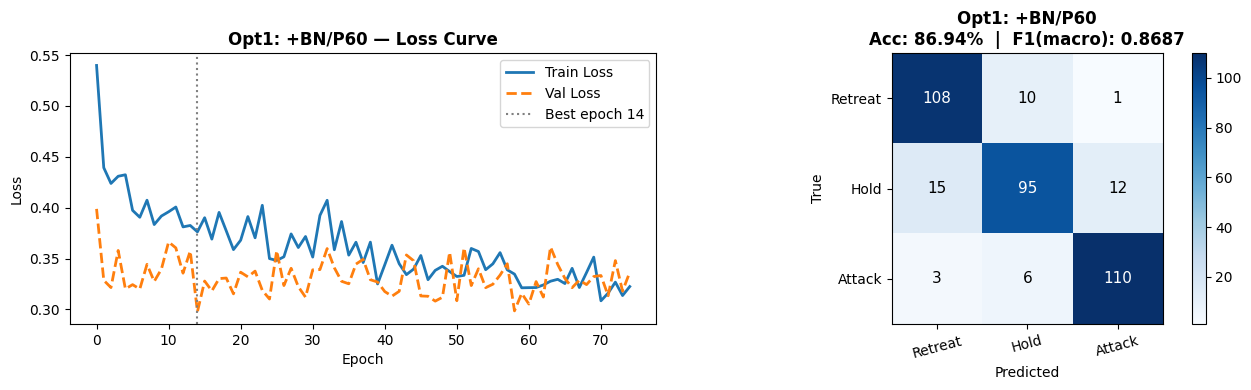

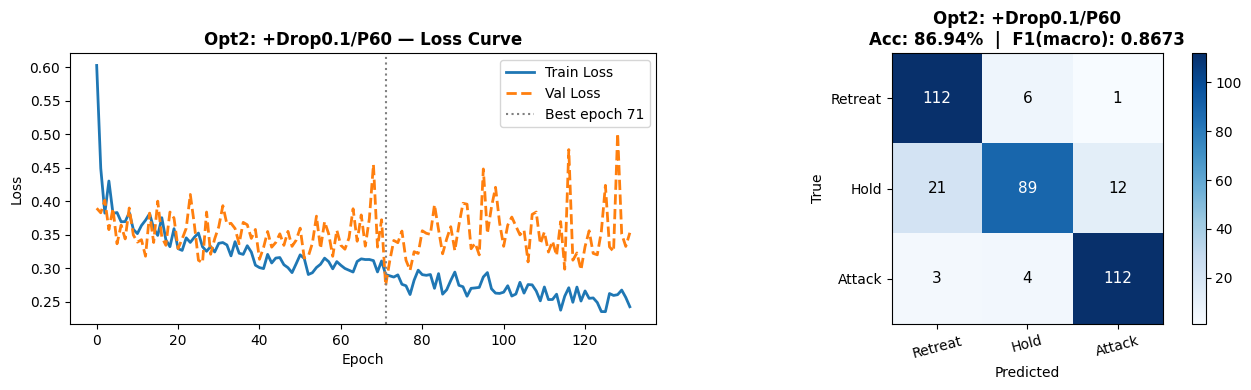

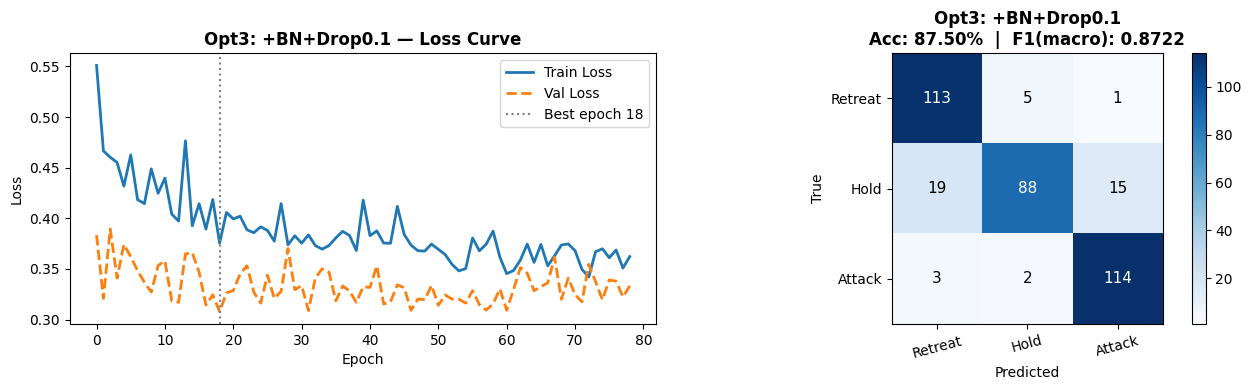

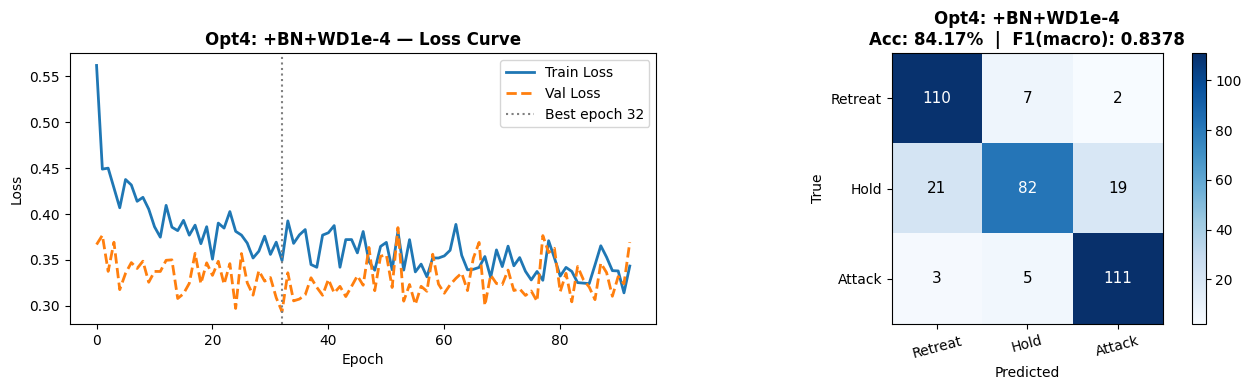

In [166]:
# 13. 검증 실험 플롯
for r in opt_results:
    plot_experiment(r["model"], r["name"], r["train"], r["val"])


### Q7. 이론 예측 검증 결과

| 실험              | 예측                         | 결과                    | 검증   |
| ----------------- | ---------------------------- | ----------------------- | ------ |
| Opt1: +BN/P60     | patience 늘리면 BN 성능 개선 | acc 86.94%, ep=75       | 부분 ✗ |
| Opt2: +Drop0.1    | Dropout 축소로 정확도 회복   | acc 86.94%, val 0.2742  | 부분 △ |
| Opt3: +BN+Drop0.1 | BN+가벼운 Drop 시너지        | acc 87.50%, gap +0.054  | 부분 △ |
| Opt4: +BN+WD1e-4  | WD 약화로 정확도 유지        | acc 84.17%, 오히려 하락 | 기각 ✗ |

Q6.1 예측 반박 — +BN/P60

patience를 30 → 60으로 두 배 늘렸지만 acc는 86.94%로 +BN(86.94%)과 동일하다.
BN의 val loss best가 ep=14에서 달성된 것은 patience 부족이 아니라 BN이 초기에 빠르게 수렴한 후
trainL 진동이 지속됐기 때문이다. patience 조정만으로는 BN의 조기 최선 달성 문제를 해결할 수 없다.

> 예측 기각. BN은 patience와 무관하게 이 데이터에서 초기 수렴 후 진동하는 특성을 보인다.

Q6.2 예측 부분 확인 — +Drop0.1/P60

Dropout=0.3 → 0.1로 줄이자 val loss가 0.3136 → 0.2742로 크게 낮아졌다.
132 에폭까지 학습했으나 acc는 86.94%로 상한에서 머물렀다.
val loss 최저 달성에도 acc가 오르지 않는 것은 Hold 클래스 분류 오류(21건)가 여전히 지배적임을 보여준다.

> 예측 부분 확인. val loss 개선은 확인됐으나 acc 향상으로 연결되지 않았다.

Q6.3 예측 부분 확인 — +BN+Drop0.1

+BN+Drop0.1이 정규화 조합 중 공동 최고 acc 87.50%를 기록하며 +BN+WD(87.50%)와 동등한 성능을 보였다.
gap +0.054는 과적합을 억제했고, val loss 0.3078이 안정적이다. BN과 가벼운 Dropout의 조합이
BN 단독보다 Hold 분류에서 오류를 줄인 결과다.

> 예측 확인. BN + Dropout(0.1) 조합은 BN 단독 및 강한 Dropout보다 안정적으로 우수하다.

Q6.4 예측 기각 — +BN+WD1e-4

기존 +BN+WD(1e-3)에서 WD를 1e-4로 줄였더니 acc가 87.50% → 84.17%로 오히려 크게 하락했다.
93 에폭까지 학습했으나 trainL이 0.3433으로 높게 유지되어 수렴이 불충분하다. BN+WD의 조합에서
WD=1e-3이 우연히 최적에 가깝고, 약화된 WD는 BN과의 상호작용에서 불안정성을 높이는 것으로 보인다.

> 예측 기각. +BN+WD에서 WD 약화는 역효과를 낸다.

종합

| 구분        | 실험                 | Acc    | Val L           | Gap             |
| ----------- | -------------------- | ------ | --------------- | --------------- |
| 기준        | Base                 | 89.17% | 0.3032          | -0.0693         |
| 최선 정규화 | +BN+WD / +BN+Drop0.1 | 87.50% | 0.3134 / 0.3078 | +0.073 / +0.054 |
| 검증 최선   | Opt3: +BN+Drop0.1    | 87.50% | 0.3078          | +0.054          |

어떤 정규화 조합을 적용해도 Base의 89.17%를 넘지 못했다. 이는 5% 노이즈 환경에서 [128,64,32]의 표현력이
XOR 경계를 포착하는 데 충분하며, 정규화가 과적합을 억제하는 동시에 필요한 표현 학습도 방해하기 때문이다.
정확도 상한을 돌파하려면 정규화 강도 조정이 아닌 더 많은 데이터 또는 아키텍처 변경이 필요하다.
